In [3]:
"""Check the output of the UQ"""
import xarray as xr
from utils.paths import *
from utils.analysis import *
import os
import itertools as it
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from matplotlib import rcParams
from glob import glob
from tqdm import tqdm
import pickle
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split, StratifiedKFold
from sklearn.utils import resample
#from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import LinearSVC, NuSVC, SVC


rcParams['font.size'] = 10
rcParams['axes.titlesize'] = 10
rcParams['figure.facecolor'] = 'w'
rcParams['axes.facecolor'] = 'w'

casename = 'UQ_20240311_US-SPR_ICB20TRCNPRDCTCBC'
#postproc_file = 'postproc_vars_SPRUCE_4'
postproc_file = ''
casename_rerun = casename # casename.replace('UQ_default', 'UQ_default_optimized')
n_rerun = 4000
pft_list = [2, 3, 11, 12]
hol_add = 17
chamber_list = ['T0.00', 'T0.00CO2', 'T2.25', 'T2.25CO2', 'T4.50', 'T4.50CO2', 'T6.75', 'T6.75CO2', 'T9.00', 'T9.00CO2', 'TAMB']


<ipython-input-2-c5238cdc5a72>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  index['year'] = [f'{i}-{j}' for i, j in zip(index['year_start'], index['year_end'])]
<ipython-input-2-c5238cdc5a72>:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  temp = allstats.loc[(var, pft), 'R2']


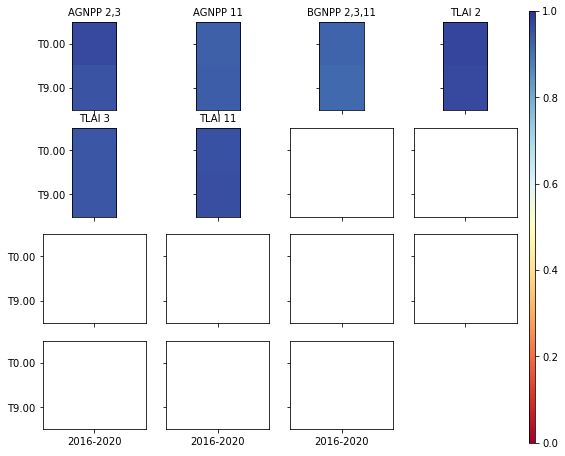

In [2]:
""" MCMC fitstats """

# Read the stats
filename = os.path.join(os.environ['HOME'], 'models', 'OLMT', 'UQ_output', casename, 'NN_surrogate', 'fitstats.txt')
f = open(filename, 'r')
allstats = [re.split(r'\s+', line.split(': ')[1]) for line in f.read().split('\n') if line[:3] == 'QOI']
allstats = pd.DataFrame([[float(line[0]), float(line[1])] for line in allstats], index = range(len(allstats)), columns = ['R2', 'RMSE'])
f.close()

# Read the column names
postproc_vars = pd.read_csv(f'./temp/{postproc_file}', sep = r'\s+')
index = postproc_vars.iloc[:, [0, 1, 2, 8, 11]]
index.columns = ['variable', 'year_start', 'year_end', 'pfts', 'chamber']
index['year'] = [f'{i}-{j}' for i, j in zip(index['year_start'], index['year_end'])]
index = index.drop(['year_start', 'year_end'], axis = 1)
allstats.index = pd.MultiIndex.from_frame(index)

# Make the plot
var_and_pft = index[['variable', 'pfts']].drop_duplicates()
fig, axes = plt.subplots(int(np.ceil(allstats.shape[0]/4)), 4, figsize = (8.5, 7.5), sharex = True, sharey = True)
count = 0
for _, row in var_and_pft.iterrows():
    ax = axes.flat[count]

    var = row['variable']
    pft = row['pfts']
    ax.set_title(f'{var} {pft}')

    try:
        temp = allstats.loc[(var, pft), 'R2']
    except:
        ax.axis('off') # combination doesn't exist
        continue

    temp = temp.unstack()

    cf = ax.imshow(temp, vmin = 0, vmax = 1., cmap = 'RdYlBu')
    ax.set_xticks(range(temp.shape[1]))
    ax.set_xticklabels(temp.columns)
    plt.setp(ax.get_xticklabels(), rotation = 90)
    ax.set_yticks(range(temp.shape[0]))
    ax.set_yticklabels(temp.index)

    count += 1
axes.flat[-1].axis('off')
cax = fig.add_axes([0.92, 0.1, 0.01, 0.8])
plt.colorbar(cf, cax = cax, orientation = 'vertical')

In [7]:
allstats

R2      RMSE
variable pfts   chamber  year                         
AGNPP    2,3    T0.00    2016-2020  0.966167  0.000813
                T9.00    2016-2020  0.951369  0.000965
         11     T0.00    2016-2020  0.928008  0.001331
                T0.00CO2 2016-2020  0.923929  0.001542
                T9.00    2016-2020  0.934405  0.001225
                T9.00CO2 2016-2020  0.926365  0.001495
BGNPP    2,3,11 T0.00    2016-2020  0.927685  0.001525
                T0.00CO2 2016-2020  0.928932  0.001406
                T9.00    2016-2020  0.896710  0.002636
                T9.00CO2 2016-2020  0.912661  0.001973
TLAI     2      T0.00    2016-2020  0.974120  0.000735
                T9.00    2016-2020  0.964758  0.000805
         3      T0.00    2016-2020  0.941812  0.002152
                T9.00    2016-2020  0.942381  0.002030
         11     T0.00    2016-2020  0.951203  0.001101
                T9.00    2016-2020  0.956444  0.000898

In [3]:
""" Performance of the ELM runs sampled from the posterior parameter distributions """
###########################################################################################
# 1. Down-select to where all 4 PFTs grew
###########################################################################################
folders = [f'g{i:05g}' for i in range(1, n_rerun+1)]
# grew = np.full((n_rerun, len(pft_list)), True)
grew = np.full(n_rerun, True)
for i in tqdm(range(n_rerun)):
    pft_grew = True
    for chamber in chamber_list:
        flist = sorted(glob(os.path.join(os.environ['PROJDIR'], 'E3SM', 'output', 'UQ', casename_rerun, folders[i], chamber, '*.h1.*.nc')))
        hr = xr.open_dataset(flist[0])
        gpp = hr['TLAI'].load() # * 86400 # s-1 to day-1
        for j, pft in enumerate(pft_list):
            if gpp[:, pft].max(axis = 0) < 1e-10:
                pft_grew = False
                break
                # grew[i, j] = False
            if gpp[:, pft + hol_add].max(axis = 0) < 1e-10:
                pft_grew = False
                break
                # grew[i, j] = False
        if pft_grew == False:
            hr.close()
            break
        hr.close()
    grew[i] = pft_grew
folders_grew = [f for i, f in enumerate(folders) if grew[i]]

with open('./temp/folders_grew.pkl', 'wb') as f:
    pickle.dump(folders_grew, f)

print('Number of valid folders:', len(folders_grew))

  0%|          | 13/4000 [00:21<1:48:39,  1.64s/it]


KeyboardInterrupt: 

In [7]:
grow_these_pfts = [2, 3, 11]
mytreatment = ['T0.00', 'T9.00']
case = 'UQ_default2_optimized_US-SPR_ICB20TRCNPRDCTCBC'
unique_treatments = np.unique(mytreatment)

#with open('./temp/folders_grew.pkl', 'rb') as f:
#    folders_grew = pickle.load(f)
folders_grew = [f'g{i:05g}' for i in range(1, 1001)]

# check if all the required PFTs grew. If not, return invalid runs.
# max_tlai = np.full((len(folders_grew), len(unique_treatments), len(grow_these_pfts)), np.nan)
max_tlai = np.full((100, len(unique_treatments), len(grow_these_pfts)), np.nan)
for count, folder in enumerate(folders_grew[::10]):
    run = int(folder[1:])

    for t, treatment in enumerate(unique_treatments):
        rundir = f'/lustre/or-scratch/cades-ccsi/scratch/ywo/E3SM/output/UQ/{case}/{folder}/{treatment}/'
        flist = [rundir+case+'.clm2.h1.'+str(10000+y)[1:]+'-01-01-00000.nc' for y in range(2016, 2021)]
        hr = xr.open_mfdataset(flist)
        tlai = hr['TLAI'].groupby('time.month').mean().max(axis = 0) # maximum LAI during the year
        for p, pft in enumerate(grow_these_pfts):
            max_tlai[count, t, p] = float(tlai[pft] * 0.64 + tlai[pft + 17] * 0.36)
        hr.close()
    
    if count == (max_tlai.shape[0] - 1):
        break

outfile = os.path.join(path_out, 'uq_examine_max_tlai.npy')
with open(outfile, 'wb') as f:
    np.save(f, max_tlai)

/home/ywo/conda_env/myCondaEnv/lib/python3.8/site-packages/dask/array/numpy_compat.py:40: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/home/ywo/conda_env/myCondaEnv/lib/python3.8/site-packages/dask/utils.py:31: RuntimeWarning: All-NaN slice encountered
  return func(*args, **kwargs)
/home/ywo/conda_env/myCondaEnv/lib/python3.8/site-packages/dask/core.py:121: RuntimeWarning: All-NaN slice encountered
  return func(*(_execute_task(a, cache) for a in args))
/home/ywo/conda_env/myCondaEnv/lib/python3.8/site-packages/dask/array/numpy_compat.py:40: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/home/ywo/conda_env/myCondaEnv/lib/python3.8/site-packages/dask/utils.py:31: RuntimeWarning: All-NaN slice encountered
  return func(*args, **kwargs)
/home/ywo/conda_env/myCondaEnv/lib/python3.8/site-packages/dask/core.py:121: RuntimeWarning: All-NaN slice encountered
  return func(*(_execute_task(a, cache) for a in args)

[None, None, None, None, None, None, None, None, None, None, None, None]

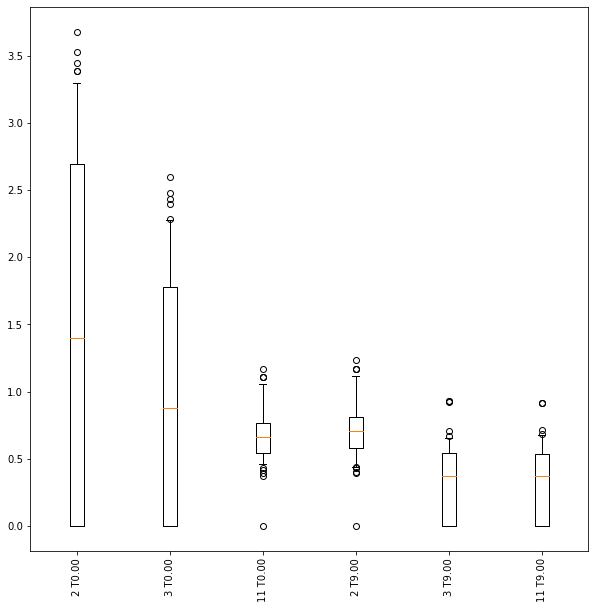

In [8]:
with open(outfile, 'rb') as f:
    max_tlai = np.load(f)

# convert from patch to grid level
max_tlai[:, :, 0] = max_tlai[:, :, 0] * 0.36
max_tlai[:, :, 1] = max_tlai[:, :, 1] * 0.14
max_tlai[:, :, 2] = max_tlai[:, :, 2] * 0.25

fig, ax = plt.subplots(figsize = (10, 10))
for t, treatment in enumerate(unique_treatments):
    for p, pft in enumerate(grow_these_pfts):
        ax.boxplot(max_tlai[:, t, p], whis = [5, 95], positions = [p * 2 + t])
ax.set_xticks(range(len(unique_treatments) * len(grow_these_pfts)))
ax.set_xticklabels([f'{pft} {treatment}' for treatment in unique_treatments for pft in grow_these_pfts])
plt.setp(ax.get_xticklabels(), rotation = 90)

In [4]:
outfile = os.path.join(path_out, 'uq_examine_max_tlai.npy')
with open(outfile, 'rb') as f:
    max_tlai = np.load(f)

In [12]:
with open('./temp/folders_grew.pkl', 'rb') as f:
    folders_grew = pickle.load(f)
for count, folder in enumerate(folders_grew[::17]):
    break
print(folder)

g00001


In [16]:
max_tlai.max(axis = 0)
#np.where((max_tlai[:, 0, 0] > 3) & (max_tlai[:, 0, 1] > 3) & (max_tlai[:, 0, 2] > 3))

array([[41.75794983, 10.36382675, 27.1113224 ],
       [38.82959366,  9.81760693, 28.326931  ]])

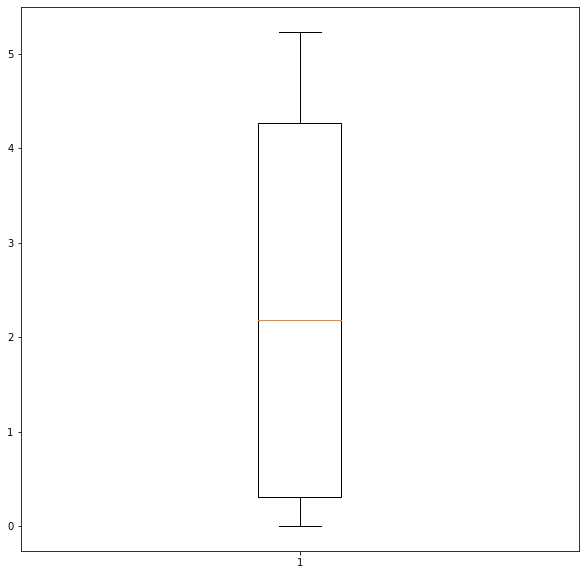

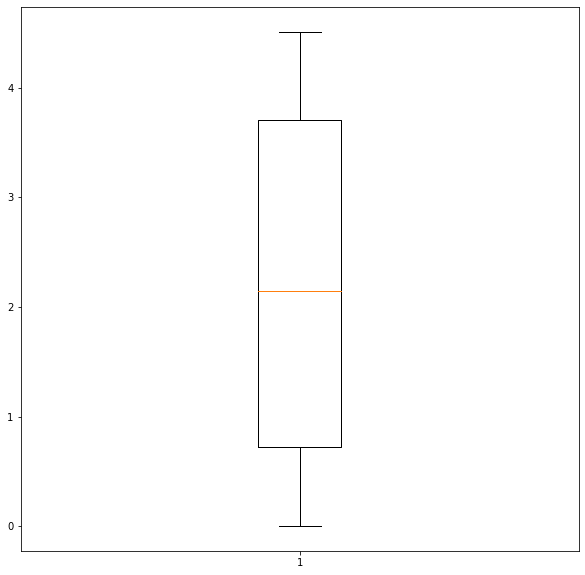

In [35]:
for t, treatment in enumerate(unique_treatments):
    """fig, axes = plt.subplots(3, 3, figsize = (10, 10))
    for p, pft in enumerate(grow_these_pfts):
        for q, pft in enumerate(grow_these_pfts):
            ax = axes[p, q]
            ax.plot(max_tlai[:, t, p], max_tlai[:, t, q], '.')
    """

    """fig, ax = plt.subplots(figsize = (10, 10), subplot_kw = dict(projection = '3d'))
    cf = ax.scatter(max_tlai[:, t, 0], max_tlai[:, t, 1], max_tlai[:, t, 2], marker = '.', s = 100)
    ax.set_xlabel('PFT = 2')
    ax.set_ylabel('PFT = 3')
    ax.set_zlabel('PFT = 11')
    ax.view_init(elev=20., azim=-35)
    """

    fig, ax = plt.subplots(figsize = (10, 10))
    ax.boxplot(max_tlai[ (max_tlai[:, t, 0] >= 2) & (max_tlai[:, t, 0] <= 4) & \
                         (max_tlai[:, t, 2] >= 0.5) & (max_tlai[:, t, 2] <= 3), t, 1])

In [ ]:
# in the optimized parameters, PFT3 and 11 never grew
# In [27]: grew.sum(axis = 0)
# Out[27]: array([3663,  183,    0, 4000])
grew.sum(axis = 0)

In [ ]:
###########################################################################################
# 2. Extract the variables and compare to the postproc file
#    All variables will take > 6 hours, check TLAI of ambient, lala
###########################################################################################
observation = pd.read_csv(os.path.join(os.environ['HOME'], 'Git', 'phenology_elm', 'temp', 'postproc_vars_SPRUCE'), sep = r'\s+', header = None, skiprows = 1)
observation.columns = ['Variable','Startyear','Endyear','Startday','Endday','AveragingPeriod','Factor','AddOffset','PFT','Obs','Obs_err','Treatment']

observation = observation.loc[(observation['Variable'] == 'TLAI') & (observation['Treatment'] == 'T0.00'), :].reset_index(drop = True)
print(observation)

with open('./temp/folders_grew.pkl', 'rb') as f:
    folders_grew = pickle.load(f)

simulation = pd.DataFrame(np.nan, index = range(observation.shape[0]), columns = folders_grew)
for i in tqdm(range(len(folders_grew))):
    for j, row in observation.iterrows():
        filename = sorted(glob(os.path.join(os.environ['PROJDIR'], 'E3SM', 'output', 'UQ', casename_rerun, folders_grew[i], row.loc['Treatment'], 
                                            f'{casename_rerun}.clm2.h1.*-01-01-00000.nc')))[:-1]
        tvec = pd.date_range('2015-01-01', '2021-12-31', freq = '1D')
        tvec = tvec[~((tvec.month == 2) & (tvec.day == 29))]
        hr = xr.open_mfdataset(filename)
        val = hr[row.loc['Variable']][(tvec.dayofyear >= row.loc['Startday']) & (tvec.dayofyear <= row.loc['Endday']), :].load().mean(axis = 0)
        val_sum = row.loc['AddOffset']
        for pft, factor in zip(row['PFT'].split(','), row['Factor'].split(',')):
            pft = int(pft)
            val_sum = val_sum + (val[pft] * float(factor) * 0.64 + val[pft + hol_add] * float(factor) * 0.36)
        simulation.loc[j, folders_grew[i]] = val_sum
        hr.close()

In [ ]:
###########################################################################################
# 3. Check what parameter combinations increase the TLAI of PFT 3
###########################################################################################
def param_list(filename):
    params = []
    f = open(os.path.join('./temp', filename))
    while True:
        line = f.readline()
        if not line:
            break
        if line == '\n':
            continue
        if line[0] == '#':
            continue
        params.append((line.split(' ')[0], line.split(' ')[1]))
    f.close()
    params = pd.MultiIndex.from_tuples(params, names = ['Parameter', 'PFT'])
    params = params.reorder_levels([1, 0])
    return params

mcsamples = pd.read_csv(os.path.join(os.environ['HOME'], 'models', 'OLMT', 'mcsamples_UQ_default_4000.txt'), sep = r'\s+', header = 0)
mcsamples.columns = param_list('parm_list_SPRUCE_default_no_sphagnum_second_trial')
mcsamples_min = mcsamples.min(axis = 0)
mcsamples_max = mcsamples.max(axis = 0)

top20 = simulation.loc[1, :].sort_values()[::-1].index[:20]
top20_vals = simulation.loc[1, :].sort_values()[::-1].values[:20]
mcsamples = mcsamples.loc[[int(g[1:]) for g in top20], :]

# Test individual parameter values
fig, axes = plt.subplots(nrows=6, ncols=5, figsize=(20, 20))
fig.subplots_adjust(hspace=0.3, wspace=0.1)

# Iterate over the axes and columns, creating histograms and median annotations
for ax, column in zip(axes.flatten(), mcsamples.columns):
    # Plot the histogram for the current column
    ax.hist(mcsamples[column], bins=5, alpha=0.75, color='steelblue', edgecolor='black')

    # Calculate the median and add a vertical line
    median = mcsamples[column].median()
    ax.axvline(median, color='red', linestyle='dashed', linewidth=2)

    # Annotate the median value
    ax.text(0.65, 0.85, f'Median: {median:.2f}', transform=ax.transAxes, fontsize=10, color='red')

    # Set the title and labels for the current subplot
    ax.set_title(f'Histogram of Column {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Frequency')

    ax.set_xlim([mcsamples_min.loc[column], mcsamples_max.loc[column]])

# Remove any remaining empty subplots
for i in range(len(mcsamples.columns), 30):
    fig.delaxes(axes.flatten()[i])

# Test ratios between parameters
fig, axes = plt.subplots(3, 3, figsize = (12, 12))
for ax, col in zip(axes.flatten(), ['br_mr', 'flnr', 'froot_leaf', 'grperc', 'mbbopt', 'q10_mr', 'slatop']):
    temp = mcsamples.loc[:, [('2', col), ('3', col), ('11', col)]]
    cf = ax.scatter(temp.iloc[:, 0] / temp.iloc[:, 1], temp.iloc[:, 2] / temp.iloc[:, 1], c = top20_vals, vmin = 0.17, vmax = 0.3, cmap = 'RdYlBu')
    plt.colorbar(cf, ax = ax)
    ax.set_title(col)

In [ ]:
###########################################################################################
# 4. Manual checking does not work
#    Fit a random forest classifier to see which parameters let all PFTs grew, and
#    which did not
###########################################################################################
mcsamples = pd.read_csv(os.path.join(os.environ['HOME'], 'models', 'OLMT', 'mcsamples_UQ_default_4000.txt'), sep = r'\s+', header = 0)
mcsamples.columns = param_list('parm_list_SPRUCE_default_no_sphagnum_second_trial')

label = np.full(mcsamples.shape[0], 0)
label[[int(i[1:])-1 for i in folders_grew]] = 1

def balance_classes(X, y):
    # Get the unique classes and their counts
    unique, counts = np.unique(y, return_counts=True)
    class_counts = dict(zip(unique, counts))

    # Find the maximum class count
    max_count = max(class_counts.values())

    # Upsample each class to match the maximum class count
    X_balanced, y_balanced = [], []
    for class_label in unique:
        mask = (y == class_label)
        X_class = X[mask]
        y_class = y[mask]

        X_upsampled, y_upsampled = resample(X_class, y_class, replace=True, n_samples=max_count, random_state=42)

        X_balanced.append(X_upsampled)
        y_balanced.append(y_upsampled)

    # Combine the upsampled classes and shuffle them
    X_balanced = np.concatenate(X_balanced, axis=0)
    y_balanced = np.concatenate(y_balanced, axis=0)
    shuffled_indices = np.random.permutation(len(y_balanced))

    return X_balanced[shuffled_indices], y_balanced[shuffled_indices]


X_train, X_test, y_train, y_test = train_test_split(mcsamples, label, random_state = 200, train_size = 0.8, stratify = label)
X_train_balanced, y_train_balanced = balance_classes(X_train, y_train)

# Check the new class distribution
unique, counts = np.unique(y_train_balanced, return_counts=True)
print("Balanced class distribution:", dict(zip(unique, counts)))

# param_grid = {
#     'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 100)],
#     'learning_rate_init': [0.001, 0.01, 0.1],
#}

# mod = XGBClassifier(n_estimators = 50)
# mod = NuSVC(nu = 0.02, tol = 1e-7)
# mod = MLPClassifier(random_state = 42, max_iter = 1000, activation = 'relu', learning_rate = 'adaptive')
# grid_search = GridSearchCV(mod, param_grid, cv = 5, scoring = 'accuracy', n_jobs = -1)
# grid_search.fit(X_train_balanced, y_train_balanced)
# mod = grid_search.best_estimator_
mod = MLPClassifier(hidden_layer_sizes = (20, 10, 10, 20), learning_rate_init = 0.001, activation = 'relu', learning_rate = 'adaptive', alpha = 0.004, max_iter = 4000)
mod.fit(X_train_balanced, y_train_balanced)
y_pred_train = mod.predict_proba(X_train)
y_pred = mod.predict_proba(X_test)
# y_pred_train = mod.predict(X_train)
# y_pred = mod.predict(X_test)

# Compare to random prediction
print('Train: ', np.sqrt(np.mean(np.power(y_train - y_pred_train[:, 1], 2))))
print('Test: ', np.sqrt(np.mean(np.power(y_test - y_pred[:, 1], 2))))
print('Baseline:', np.sqrt(np.mean(np.power(y_test - np.mean(y_train), 2))))

In [ ]:
""" Recreate the sensitivity analysis graph """
# the rows are parameters, columns are observations
postproc_vars = pd.read_csv('./temp/postproc_vars_SPRUCE', sep = r'\s+')
colnames = pd.MultiIndex.from_tuples([(i, j) for i, j in zip(postproc_vars['#Variable'], postproc_vars['add'])], names = ['Variable', 'PFT'])
params = param_list('parm_list_SPRUCE_default_no_sphagnum_second_trial')

#Plot main sensitivity indices
filename = os.path.join(os.environ['HOME'], 'models', 'OLMT', 'UQ_output', casename, 'GSA', 'sens_main.txt')
sens_main = pd.read_csv(filename, sep = r'\s+', header = None)
sens_main.columns = colnames
sens_main.index = params
sens_main = sens_main.sort_index().sort_index(axis = 1)

fig, axes = plt.subplots(1, 6, figsize = (30, 6), sharey = True)
sens_main.loc[:, ('TLAI', '2')].plot.barh(ax = axes.flat[0])
sens_main.loc[:, ('TLAI', '3')].plot.barh(ax = axes.flat[1])
sens_main.loc[:, ('TLAI', '11')].plot.barh(ax = axes.flat[2])
sens_main.loc[:, ('AGNPP', '2,3')].plot.barh(ax = axes.flat[3])
sens_main.loc[:, ('AGNPP', '11')].plot.barh(ax = axes.flat[4])
sens_main.loc[:, ('BGNPP', '2,3,11')].plot.barh(ax = axes.flat[5])

#Total sensitivity indices
filename = os.path.join(os.environ['HOME'], 'models', 'OLMT', 'UQ_output', casename, 'GSA', 'sens_tot.txt')
sens_tot = pd.read_csv(filename, sep = r'\s+', header = None)
sens_tot.columns = colnames
sens_tot.index = params
sens_tot = sens_tot.sort_index().sort_index(axis = 1)

fig, axes = plt.subplots(1, 6, figsize = (30, 6), sharey = True)
sens_tot.loc[:, ('TLAI', '2')].plot.barh(ax = axes.flat[0])
sens_tot.loc[:, ('TLAI', '3')].plot.barh(ax = axes.flat[1])
sens_tot.loc[:, ('TLAI', '11')].plot.barh(ax = axes.flat[2])
sens_tot.loc[:, ('AGNPP', '2,3')].plot.barh(ax = axes.flat[3])
sens_tot.loc[:, ('AGNPP', '11')].plot.barh(ax = axes.flat[4])
sens_tot.loc[:, ('BGNPP', '2,3,11')].plot.barh(ax = axes.flat[5])

In [ ]:
""" TRY database """
data = pd.read_csv(os.path.join(path_input, '25911.txt'), sep = '\t', encoding = 'ISO-8859-1')
data = data.loc[data['TraitID'].isin([12, 1778, 146, 4083, 3086, 3115, 3116, 3117]), ['DataName', 'AccSpeciesName', 'OrigValueStr', 'UnitName']]
data['OrigValueStr'] = data['OrigValueStr'].astype(float)
data = pd.concat([data.groupby(['DataName', 'AccSpeciesName']).mean(), data.groupby(['DataName', 'AccSpeciesName']).std(), data.groupby(['DataName', 'AccSpeciesName']).first()['UnitName']], axis = 1)
data.columns = ['ValueMean', 'ValueStd', 'Unit']
# data.index = data.index.reorder_levels(['AccSpeciesName', 'DataName'])
# data = data.sort_index()
filt_sla = data.index.get_level_values('DataName').isin(['SLA: petiole  excluded', 'SLA: petiole  included', 'SLA: petiole included (1)', 'SLA: undefined if petiole in- or excluded', 'SLA: undefined if petiole in- or excluded (1)'])
data.loc[filt_sla, 'ValueMean'] = data.loc[filt_sla, 'ValueMean'] / 1000.
data.loc[filt_sla, 'ValueStd'] = data.loc[filt_sla, 'ValueStd'] / 1000.
data.loc[filt_sla, 'Unit'] = 'm2 g-1'
data